### Diabetes Prediction- LightGBM vs XGBoost

In [56]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import lightgbm as lgb
import xgboost as xgb


In [57]:
# load the dataset
df=pd.read_csv('diabetes.csv')

In [58]:
# display first 5 rows 
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##### Exploratory Data Analysis (EDA)

In [59]:
# check missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [60]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [61]:
# statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


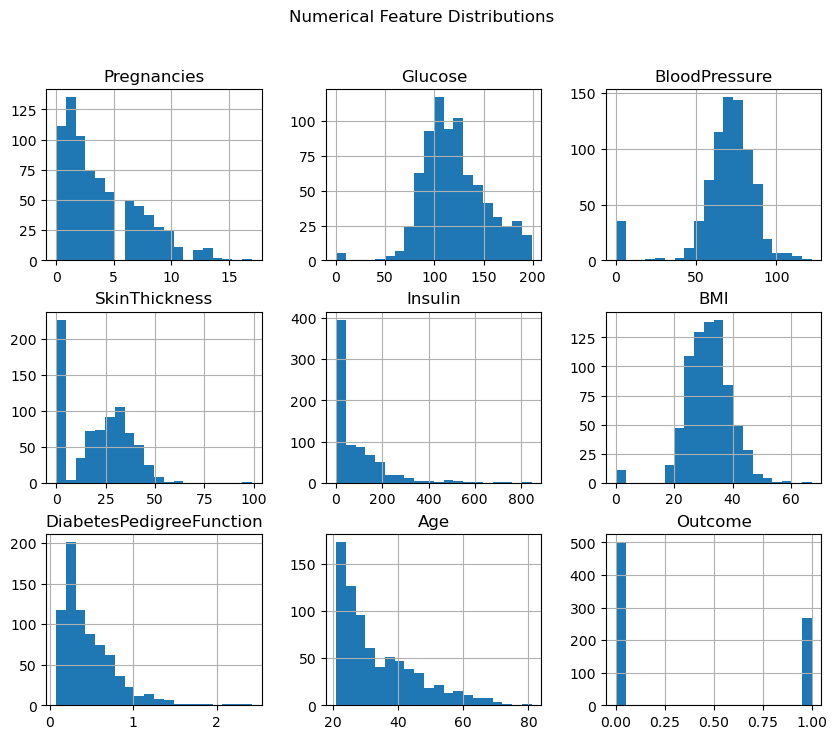

In [62]:
# Visualize distribution of numerical columns
df.hist(figsize=(10,8), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [63]:
# select only numeric columns for outlier detection
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumeric Columns for Outlier Analysis:")
print(list(numeric_cols))


Numeric Columns for Outlier Analysis:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


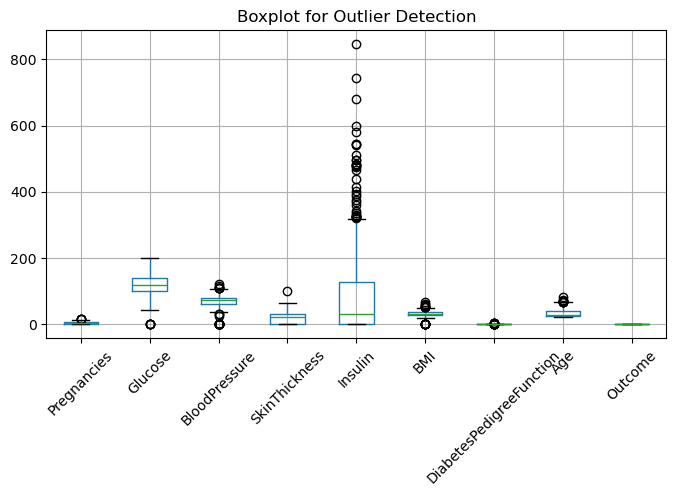

In [64]:
# check outliers using Boxplots
plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [65]:
# Detect Outliers Using IQR (Interquartile Range) Method
def detect_outliers_iqr(data):
    outlier_indices = {}
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        outlier_indices[col] = outliers.index.tolist()
    return outlier_indices

outlier_indices = detect_outliers_iqr(df[numeric_cols])
print("\nOutliers detected using IQR method:")
for col, indices in outlier_indices.items():
    print(f"{col}: {len(indices)} outliers")



Outliers detected using IQR method:
Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers
Outcome: 0 outliers


In [66]:
# Remove outliers
df_no_outliers = df.drop(index=set(sum(outlier_indices.values(), [])))

# OR Cap (winsorize) outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)


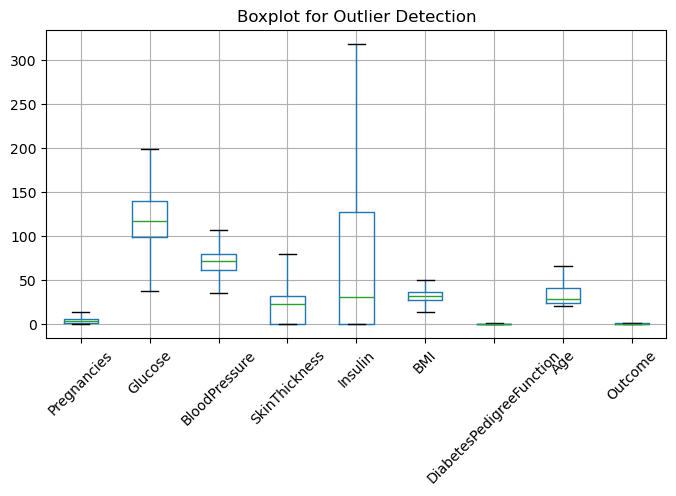

In [67]:
# check if outliers are removed
plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

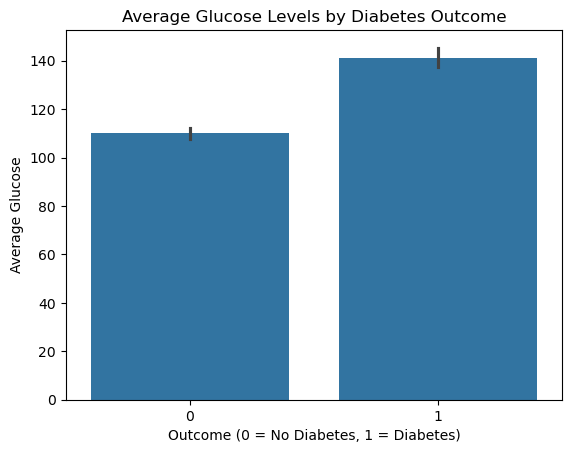

In [35]:
# Barplot
sns.barplot(x='Outcome', y='Glucose', data=df, estimator=np.mean)
plt.title("Average Glucose Levels by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Average Glucose")
plt.show()

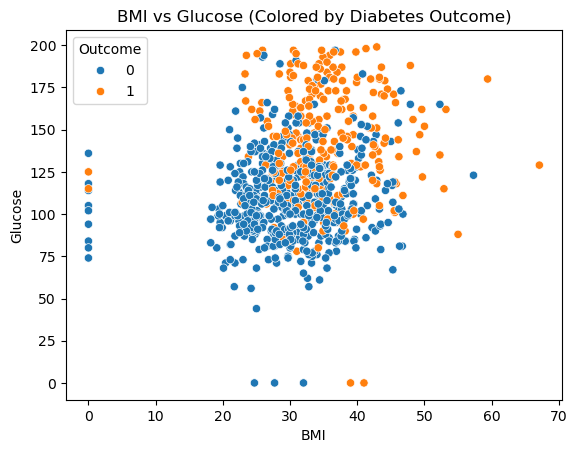

In [36]:
# Scatter plot
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df)
plt.title("BMI vs Glucose (Colored by Diabetes Outcome)")
plt.show()

##### Data Preprocessing

In [37]:
# Replace zero values in specific columns with median (as zeros are invalid readings)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

In [38]:
# Check again for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [71]:
# No categorical encoding is needed as all columns are numeric
# Verify processed data
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72,35,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66,29,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64,0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66,23,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40,35,168.0,43.1,1.200,33.0,1


#####  Split Data

In [39]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##### Model Evaluation Function

In [40]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"\n===== {model_name} Evaluation =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    

##### LightGBM Model

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


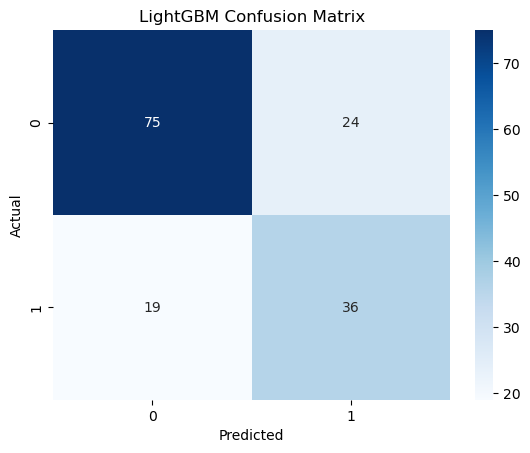

In [41]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

evaluate_model(lgb_model, X_test, y_test, "LightGBM")

##### XGBoost Model


===== XGBoost Evaluation =====
Accuracy: 0.7142857142857143
Precision: 0.5873015873015873
Recall: 0.6727272727272727
F1 Score: 0.6271186440677966

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77        99
           1       0.59      0.67      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



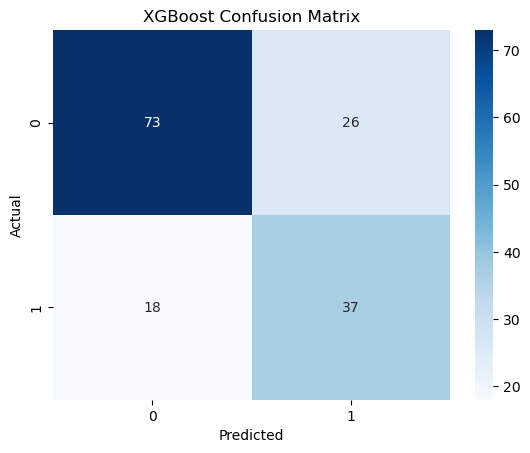

In [42]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test, "XGBoost")


##### Cross-Validation (Accuracy)

In [43]:
lgb_cv = cross_val_score(lgb_model, X, y, cv=5, scoring='accuracy').mean()
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy').mean()

print(f"\nLightGBM CV Accuracy: {lgb_cv:.4f}")
print(f"XGBoost CV Accuracy:  {xgb_cv:.4f}")

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [44]:
print(f"\nLightGBM CV Accuracy: {lgb_cv:.4f}")
print(f"XGBoost CV Accuracy:  {xgb_cv:.4f}")



LightGBM CV Accuracy: 0.7526
XGBoost CV Accuracy:  0.7448


##### Comparative Visualization

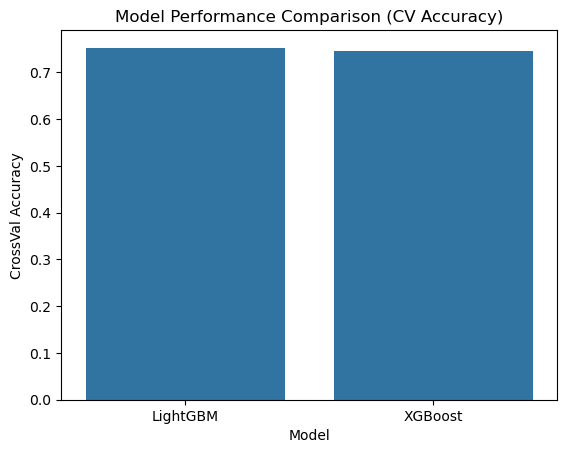

In [45]:
results = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'CrossVal Accuracy': [lgb_cv, xgb_cv]
})

sns.barplot(x='Model', y='CrossVal Accuracy', data=results)
plt.title("Model Performance Comparison (CV Accuracy)")
plt.show()

##### Summary Report


================ Advanced Model Summary =================
 Best Performing Model: LightGBM
Cross-Validated Accuracy: 0.7526

----- LightGBM Metrics -----
Accuracy : 0.7208
Precision: 0.6000
Recall   : 0.6545
F1-Score : 0.6261
Confusion Matrix:


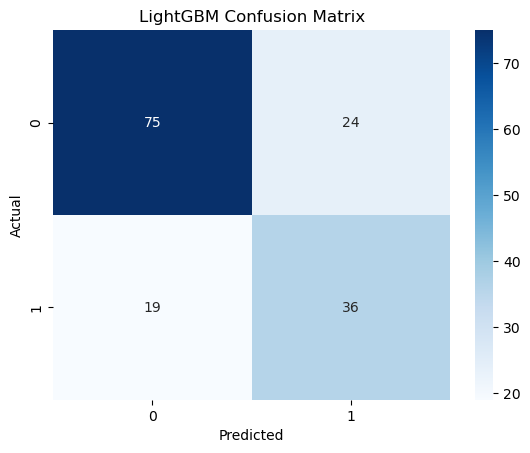



----- XGBoost Metrics -----
Accuracy : 0.7143
Precision: 0.5873
Recall   : 0.6727
F1-Score : 0.6271
Confusion Matrix:


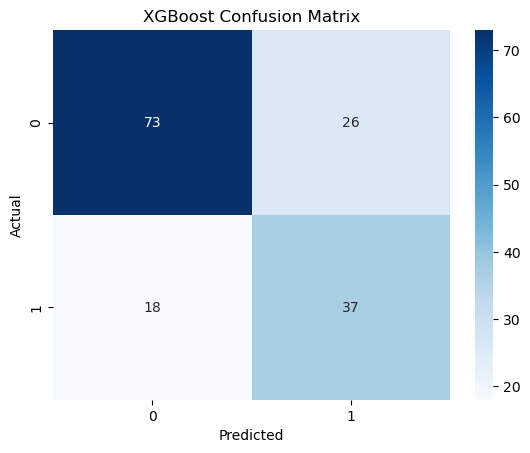



Feature Importance for Best Model:
                    Feature  Importance
6  DiabetesPedigreeFunction         488
1                   Glucose         424
5                       BMI         416
7                       Age         328
2             BloodPressure         255
3             SkinThickness         200
0               Pregnancies         166
4                   Insulin         161


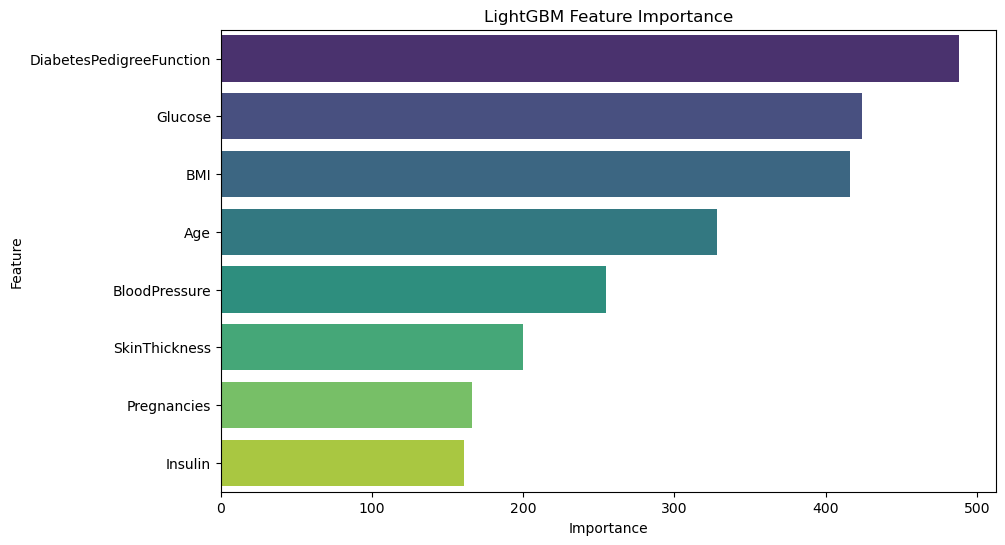


Practical Insights:
1. Glucose, BMI, Age, and DiabetesPedigreeFunction are the most influential features predicting diabetes.
2. LightGBM and XGBoost both perform well; differences in accuracy are minimal.
3. For large datasets, LightGBM may train faster due to its efficiency.
4. XGBoost provides slightly more robust handling for noisy data and complex feature interactions.
5. Both models can be deployed for early diabetes risk prediction in clinical applications.



In [69]:
# Advanced Summary Report
print("\n================ Advanced Model Summary =================")

# Compare CV Accuracy
if lgb_cv > xgb_cv:
    best_model_name = "LightGBM"
    best_score = lgb_cv
else:
    best_model_name = "XGBoost"
    best_score = xgb_cv

print(f" Best Performing Model: {best_model_name}")
print(f"Cross-Validated Accuracy: {best_score:.4f}\n")

# Evaluate metrics on test set
models = {"LightGBM": lgb_model, "XGBoost": xgb_model}
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"----- {name} Metrics -----")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("\n")

# Feature Importance for Best Model
best_model = models[best_model_name]
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance for Best Model:")
print(importance)

# Visualization of Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance, palette="viridis")
plt.title(f"{best_model_name} Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Practical Insights
print("\nPractical Insights:")
print("1. Glucose, BMI, Age, and DiabetesPedigreeFunction are the most influential features predicting diabetes.")
print("2. LightGBM and XGBoost both perform well; differences in accuracy are minimal.")
print("3. For large datasets, LightGBM may train faster due to its efficiency.")
print("4. XGBoost provides slightly more robust handling for noisy data and complex feature interactions.")
print("5. Both models can be deployed for early diabetes risk prediction in clinical applications.\n")


                                                            Submitted by: Meghana C Varghese